In [240]:
import numpy as  np
import pandas as pd
from nltk.corpus import stopwords
import  re
from nltk.stem import PorterStemmer
import nltk
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score,KFold

DOWNLOADING STOP  WORDS

In [241]:
nltk.download("stopwords")
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LOAD AND INSPECT DATA

In [242]:
df= pd.read_csv("/content/final_balanced_dataset.csv")

In [243]:
df.head()

,Comment,Sentiment
0,brings back so many memories this movie is so...,positive
1,lakshya legit killed them with facts love the ...,negative
2,dotcomnirvan never disapointedfire visual,positive
3,love it animations everything kudos for you an...,positive
4,hay lắm lun,positive


In [244]:
df.shape

(12162, 2)

DATA CLEANING

In [245]:
df.isnull().sum()

,0
Comment,2
Sentiment,0


In [246]:
df=df.dropna()

In [247]:
print(df.isnull().sum())

Comment      0
Sentiment    0
dtype: int64


In [248]:
df["Sentiment"].value_counts()

,count
Sentiment,
positive,8220
negative,3940


In [249]:
df["Sentiment"]=df["Sentiment"].replace({"positive":1,"negative":0})

/tmp/ipython-input-264221907.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Sentiment"]=df["Sentiment"].replace({"positive":1,"negative":0})


In [250]:
df.head()

,Comment,Sentiment
0,brings back so many memories this movie is so...,1
1,lakshya legit killed them with facts love the ...,0
2,dotcomnirvan never disapointedfire visual,1
3,love it animations everything kudos for you an...,1
4,hay lắm lun,1


TEXT PROCESSING

In [251]:
port=PorterStemmer()
def steming(context):
  stemmed=re.sub("[^a-zA-z]"," ",context)
  stemmed=stemmed.lower()
  stemmed=stemmed.split()
  stemmed=[port.stem(word) for word in stemmed if word not in stopwords.words("english")]
  stemmed=" ".join(stemmed)
  return stemmed

In [252]:
df["comment"]=df["Comment"].apply(steming)

In [253]:
x=df["comment"]
y=df["Sentiment"]

TRAIN-TEST-SPLI AND VECTORIZATION

In [254]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [255]:
vector=TfidfVectorizer()
x_train=vector.fit_transform(x_train)
x_test=vector.transform(x_test)

LOGISTIC REGRESSION TRAINING AND TESTING

In [256]:
model=LogisticRegression(class_weight="balanced")
model.fit(x_train,y_train)
from sklearn.metrics import  accuracy_score
y_pred=model.predict(x_train)
accuracy=accuracy_score(y_train,y_pred)
print(accuracy)

0.9196011513157895


In [257]:
model=LogisticRegression(class_weight="balanced")
model.fit(x_train,y_train)
from sklearn.metrics import  accuracy_score
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8976315789473685


OTHER MODEL EVALUATION  
->> SVM:  86
->> Random Forest: 79
->> Decision Tree: 75
->> KNN: 73


In [258]:
'''dictionary={
    "logistic regression":LogisticRegression(),
    "svm":SVC(),
    "random forest":RandomForestClassifier(),
   "DecisionTree":DecisionTreeClassifier(),
    "KNN":KNeighborsClassifier(),
}
for name,model in dictionary.items():
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred)
  print(name,accuracy)'''

'dictionary={\n    "logistic regression":LogisticRegression(),\n    "svm":SVC(),\n    "random forest":RandomForestClassifier(),\n   "DecisionTree":DecisionTreeClassifier(),\n    "KNN":KNeighborsClassifier(),\n}\nfor name,model in dictionary.items():\n  model.fit(x_train,y_train)\n  y_pred=model.predict(x_test)\n  accuracy=accuracy_score(y_test,y_pred)\n  print(name,accuracy)'

CROSS  VALIDATION

In [259]:
kfold=KFold(n_splits=5,shuffle=True,random_state=0)
cv=cross_val_score(model,x_train,y_train,cv=kfold)

In [260]:
print("logistic regression cv",cv)
print("logisstic regresision cv",cv.mean())



logistic regression cv [0.91675231 0.91521069 0.91829394 0.9311054  0.91979434]
logisstic regresision cv 0.9202313360475776


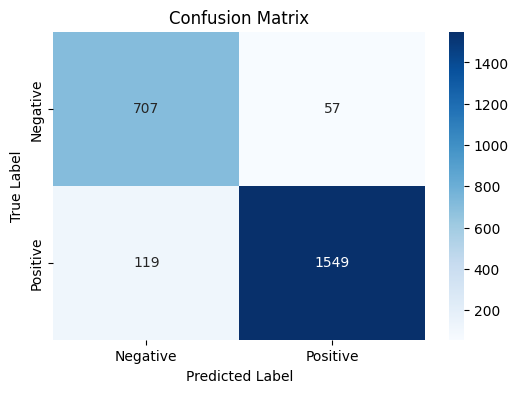

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True,fmt='d', cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


PREDICT FUNCTION

In [266]:
port2=PorterStemmer()
def predict(text):
  text=re.sub("[^a-zA-Z]"," ",text)
  text=text.lower()
  text=text.split()
  text=[port2.stem(word) for word in text if word not in stopwords.words("english")]
  text=" ".join(text)
  text=[text]
  text=vector.transform(text)
  output=model.predict(text)
  if output[0]==1:
    return "positive"
  else:
    return "negative"

print(predict("The audio quality is terrible, I couldn’t even hear properly."))
print(predict("Completely misleading, the content didn’t match the title."))
print(predict("Too many glitches, the app crashes all the time."))
print(predict("Very disappointed, I expected much better performance."))
print(predict("The customer support was rude and unhelpful."))
print(predict("Looks cheap and poorly made, not worth the money."))
print(predict("Boring and unoriginal, I lost interest quickly."))
print(predict("The delivery was late and the packaging was damaged."))
print(predict("Waste of time, I regret watching this."))
print(predict("It keeps lagging and freezing, extremely frustrating."))
print(predict("Amazing experience, everything worked flawlessly!"))
print(predict("High quality and excellent design, I love it."))
print(predict("Very helpful and informative, exceeded my expectations."))
print(predict("Fast service and great support, really impressed."))
print(predict("Absolutely worth it, I would buy again without hesitation."))
print(predict("i will forever acknowledge this channel with the help of your lessons and ideas explanations now its quite helpful while youll just sit at your comfort and monitor your account growth"))
print(predict("apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards"))
print(predict("good video these are the kinds of topics and discussions the gaming industry needs to need to be having now publishers developers the media and gamers themselves have to throw one in though for every game with a yearly release i also have to point out games with decade or more release cycle how long between gta 5 and 6 fallout 4 and 5 skyrim and elder scrolls 6"))
print(predict("this is great focus is key a playful approach can also speed things up depending on how you learn and of course patience for those interested in r and python the latest r studio ide is great and allows you to run both side by side with reticulate it can seem a steep curve but those with a grounding in r and statistics you can run ml scripts side by side and learn the similarities and where they differ"))
print(predict("hey daniel just discovered your channel a couple days ago and im learning lots thank you"))
print(predict("i used to preorder games to get the “collectible” toy that was sought after the items got really cheap really fast not worth it they also tell you that there may not be enough copies that never happened there was always enough copies"))
print(predict("i wish developers would realize that forced drm and internet connectivity for games is a step backward look at the debacles gt7 and simcity have endured whats the point of paying a full 70 for the game if there is no guarantee you can play it at your leisure especially if this ridiculous requirement is in place for singleplayer modes in my opinion at that point you cant help but wonder if spending time with the game is either fun or just another full time job this is not why people play games"))
print(predict("whenever i go to a place that doesn’t take apple pay doesn’t happen too often it’s such a drag between ‘contactless covid’ habits and my getting the apple card i’ve gotten so used to apple pay that i get seriously annoyed when a store doesn’t take it it feels like a shock it’s crazy how quickly it took over my shopping routine i’ve officially been brainwashed by apple because now it feels so inconvenient to even carry a physical card in my pocket"))
print(predict("all these people commenting im poor and i got a 1300 by studying a lot we are talking about that poor people on average are less likely to get a great score not that its impossible there is a difference between inequality in general and a specific success story"))
print(predict("the one that annoyed me was the borderlands 1 when to obtain you had to play online with someone from gearbox or with someone who already had the trophy they changed it for the rerelease to playing with three players at once"))




negative
negative
negative
negative
negative
positive
negative
negative
negative
negative
positive
positive
positive
positive
negative
positive
negative
positive
positive
positive
negative
negative
negative
negative
negative
positive
positive
positive
positive
positive


SAVING MODEL AND VECTORIZER

In [263]:
import pickle as pk
pk.dump(model,open("model.pkl","wb"))
pk.dump(vector,open("vector.pkl","wb"))
